##  RNN(Recurrent Neural Network) : 
- 순차적인 데이터를 입력 받아 결과값을 도출하는데 사용되는 딥러닝 모델, 자연어 처리에 상당히 많이 사용
- 이전 입력 값들이 현재 입력 값의 출력 값(품사)에 영향을 주는 신경망을 순환신경망 
- 출력의 결과가 다음 입력에 그대로 영향을 미친다 
- 활성화 함수 : tanh(x) -> 높은 정확도 (최대값은 1을 넘지 않고, 최소값은 -1을 넘지 않는다)

In [25]:
# IMDB(internet Movies DataBase) 리뷰 데이터 셋
from tensorflow.keras.datasets import imdb

# num_words=500 저장되어 있는 댓글들의 단어열거해서 단어횟수 순으로 정렬했을때 빈번한 단어중 상위 500개의 단어만 추출
(train_input, train_target), (test_input, test_target)  = imdb.load_data(num_words=500) 

In [26]:
print(train_input.shape, test_input.shape)

(25000,) (25000,)


In [27]:
print(len(train_input[0]), len(train_input[1]), len(train_input[2]))

218 189 141


In [28]:
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [29]:
print(train_input[13])

[1, 259, 37, 100, 169, 2, 2, 11, 14, 418, 7, 2, 2, 8, 28, 68, 419, 2, 75, 28, 4, 2, 2, 2, 173, 58, 2, 322, 19, 2, 32, 120, 41, 2, 2, 2, 39, 2, 2, 34, 35, 2, 492, 150, 59, 9, 2, 2, 2, 32, 120, 4, 2, 2, 4, 2, 38, 2, 2, 2, 8, 2, 2, 2, 41, 2, 11, 2, 2, 75, 28, 4, 2, 37, 2, 46, 34, 2, 6, 2, 37, 43, 2, 8, 30, 27, 2, 442, 2, 19, 90, 88, 29, 385, 99, 2, 5, 2, 34, 2, 27, 2, 2, 260, 383, 19, 41, 2, 5, 95, 2, 41, 56, 75, 28, 4, 2, 37, 9, 2, 2, 34, 27, 2, 5, 37, 266, 344, 5, 2, 27, 2, 25, 67, 45, 32, 2, 2, 2, 4, 64, 2, 2, 11, 14, 2, 2, 7, 2, 9, 54, 4, 2, 2, 27, 2, 2, 45, 6, 52, 155, 14, 2, 16, 324, 23, 374, 88, 2, 51, 6, 437, 7, 2, 22, 12, 62, 30, 48, 15, 232, 37, 2, 2, 2, 8, 30, 2, 11, 14, 2, 9, 66, 2, 57, 2, 91, 84, 104, 2, 26, 2, 75, 219, 14, 2, 20, 95, 276, 23, 2, 255, 4, 2, 449, 61, 2, 12, 16, 6, 2, 17, 8, 63, 31, 16, 433, 51, 9, 170, 23, 11, 2, 134, 2, 2, 2, 2]


In [30]:
print(train_target[:20])  # 20개의 정답 데이터, 1 : 긍정의 리뷰, 0 : 부정의 리뷰

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [31]:
# 훈련 세트에서 1(문장의 시작), 2(어휘 사전에 없는 단어) 제외하기, 어휘 사전 : num_words에 빈번하게 등장하는 500개 단어

for i in range(len(train_input)):
    train_input[i] = [w for w in train_input[i] if w > 2]  # w : 2 초과되는 값(w > 2), 0,1,2 필터한 3이상의 값
    
print(print(train_input[0]))

[14, 22, 16, 43, 65, 458, 66, 4, 173, 36, 256, 5, 25, 100, 43, 112, 50, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 336, 385, 39, 4, 172, 17, 38, 13, 447, 4, 192, 50, 16, 6, 147, 19, 14, 22, 4, 469, 4, 22, 71, 87, 12, 16, 43, 38, 76, 15, 13, 4, 22, 17, 17, 12, 16, 18, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 16, 480, 66, 33, 4, 130, 12, 16, 38, 5, 25, 124, 51, 36, 135, 48, 25, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 8, 4, 107, 117, 15, 256, 4, 7, 5, 36, 71, 43, 476, 26, 400, 317, 46, 7, 4, 13, 104, 88, 4, 381, 15, 297, 98, 32, 56, 26, 141, 6, 194, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 88, 12, 16, 283, 5, 16, 113, 103, 32, 15, 16, 19, 178, 32]
None


In [32]:
from sklearn.model_selection import train_test_split

# train_test_split() 함수, 학습 데이터를 80%, 검증 데이터로 20%
train_input, val_input, train_target, val_target = \
    train_test_split(train_input, train_target, test_size=0.2,
                 random_state=42)

In [33]:
import numpy as np

lengths = np.array([len(x) for x in train_input]) # 리뷰 1개당 단어의 갯수 카운트

In [34]:
print(np.mean(lengths), np.median(lengths)) # 평균, 중위수

# 163.908 126.0  -> 평균과 중위수 값이 상당한 차이가 있다.

164.67985 126.0


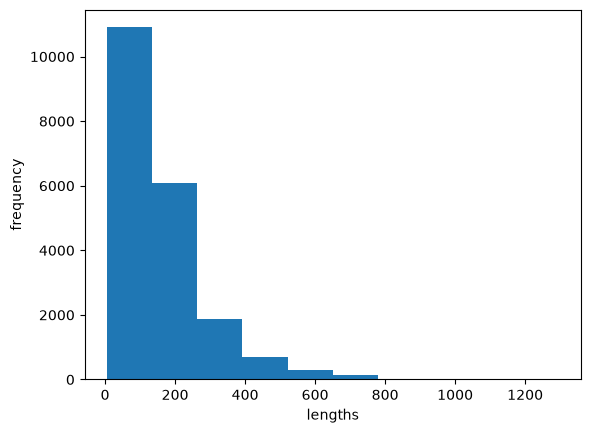

In [35]:
import matplotlib.pyplot as plt

plt.hist(lengths)
plt.xlabel('lengths')
plt.ylabel('frequency')
plt.show()

# 대부분의 리뷰글은 100글자 미만으로 작성

In [36]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 시퀸스 데이터의 길이를 맞춰 줌(댓글의 입력 길이를 일정하게(maxlen=100) 고정)
# padding='pre' 앞부분을 잘라낸 100글자가 남을때 까지 셋팅
train_seq = pad_sequences(train_input, maxlen=100, padding='pre')  # 8:2의 비율 : 25000의 80% -> 20000
train_seq.shape

(20000, 100)

In [37]:
train_seq[0] # 100글자 이상의 데이터

array([184,  13, 384,  48,  14,  16, 147,  59,  62,  69,  12,  46,  50,
         9,  53,  74,  11,  14,  31, 151,  10,  10,   4,  20,   9, 364,
       352,   5,  45,   6,  33, 269,   8, 142,   5,  17,  73,  17, 204,
         5,  19,  55,  92,  66, 104,  14,  20,  93,  76, 151,  33,   4,
        58,  12, 188, 151,  12, 215,  69, 224, 142,  73, 237,   6,   7,
       188, 103,  14,  31,  10,  10, 451,   7,   5,  80,  91,  30,  34,
        14,  20, 151,  50,  26, 131,  49,  84,  46,  50,  37,  80,  79,
         6,  46,   7,  14,  20,  10,  10, 470, 158], dtype=int32)

In [38]:
train_seq[101] # 리뷰 글자의 수는 100개 이하, 8개가 0으로 채워져 있음(padding='pre'로 셋팅)

array([  0,   0,   0,   0,   0,   0,   0,   0,  14,   9,  34, 230,   4,
       249,  20,  13,  28, 126, 110,  11,   4, 438, 100,  24,  18,  12,
         8, 130,   8,  97, 433,  12,   9, 348,   6,  38,  25,  81,  24,
        67, 259, 397, 324,  43,   8,   4,  60, 397,  16,  46,  99, 111,
       139,  71,   8,  11,   4,  17,  13, 104,   4,  12,  62, 116,  16,
        87,  21,  15,   5,   4,  85,  37, 299, 191,  60,  16,  10,  10,
        13,  62,  24, 106,  14,  18, 174,   5,  13,  32, 409,  37, 332,
        14,   8,  81,  43,   4, 172,  25,  28,  77], dtype=int32)

In [40]:
print(train_input[0][-10:]) # 원본 데이터의 끝 확인

[79, 6, 46, 7, 14, 20, 10, 10, 470, 158]


In [ ]:
val_seq = pad_sequences(val_input, maxlen=100)  # val_input 검증용 데이터도 100으로 고정

## 순환 신경망  만들기

In [41]:
from tensorflow import keras

In [ ]:
# 신경망 구성
model = keras.Sequential()

# 입력 레이어
model.add(keras.Input(shape=(100, 500))) # num_words=500

model.add(keras.layers.SimpleRNN(8))  # RNN(Recurrent Neural Network) 알고리즘

# 출력 레이어
model.add(keras.layers.Dense(units=1, activation='sigmoid')) # units=1 출력의 갯수(긍정, 부정)

In [43]:
# onehot 인코딩 방식(to_categorical() 함수)
# 출력단은 총 출력의 갯수만큼 만들어져야 함(해당 되는 row는 1, 나머지는 전부 0)

train_oh = keras.utils.to_categorical(train_seq)  # train_seq : 20000개의 리뷰 데이터 셋
train_oh.shape

(20000, 100, 500)

In [45]:
# 검증용 데이터

val_oh = keras.utils.to_categorical(val_seq)
val_oh.shape

(5000, 100, 500)

In [46]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         4,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# 해당 데이터를 onehot 인코딩 방식으로 정의했으므로 손실함수는 binary_crossentropy
model.compile(loss='binary_crossentropy',
              optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              metrics=['accuracy'])

In [ ]:
# ModelCheckpoint() 최적의 알고리즘을 찾으면 저장(완성된 모델)
# EarlyStopping() 손실이 더 적어지거나 더 커지지 않도록 조기 종료

check_cb = keras.callbacks.ModelCheckpoint('best_RNN_model.h5', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [ ]:
history = model.fit(train_oh, train_target, epochs=100, batch_size=64,
                   validation_data=(val_oh, val_target),
                   callbacks=[check_cb, early_stopping])

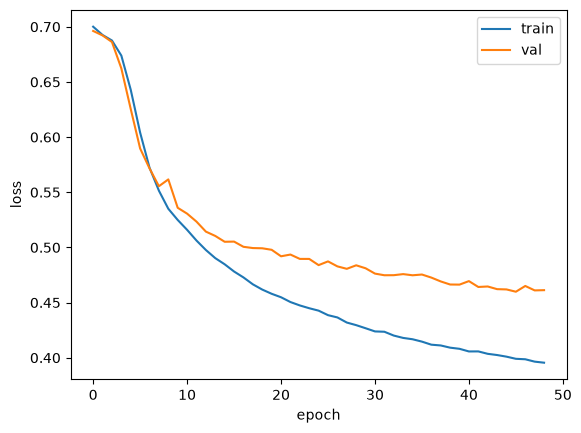

In [51]:
# onehot 인코딩 방식
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

## 단어 임베딩 사용하기

In [52]:
# List로 모델 신경망 구성을 direct로 정의

model2 = keras.Sequential([
    keras.Input(shape=(100,)),  # 입력 레이어, 리뷰는 100개의 단어로 고정
    keras.layers.Embedding(     # 단어 임베딩은 각 단어를 고정된 크기의 실수 벡터로 변환
        input_dim=500,  # num_words=500
        output_dim=16
    ),
    keras.layers.SimpleRNN(8),  # RNN(Recurrent Neural Network) 순환 신경망
    keras.layers.Dense(1, activation='sigmoid')
])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 임베딩 모델 사용 Embedding() 사용
# 조기종료 모델 탑재, EarlyStopping()
model2.compile(loss='binary_crossentropy',
               optimizer=keras.optimizers.Adam(learning_rate=1e-4),
               metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best_embeddingRnn_model.h5',
                                                 save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model2.fit(train_seq, train_target, epochs=50, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

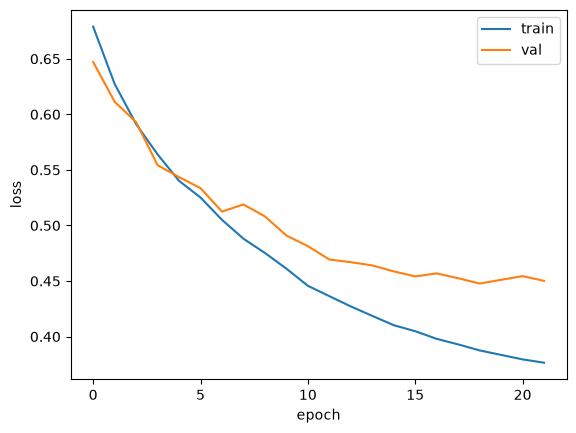

In [54]:
# Embedding 방식
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')  # 반복횟수
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()